<img src="https://userweb.fct.unl.pt/~jmc.xavier/MSII/iLogos/logo_novafct.png" style="width: 30%;">

# Departamento de Engenharia Mecânica e Industrial
## Mecânica dos Sólidos II

## Deslocamentos transversais de vigas

### Problema 8

A viga ABCD está simplesmente apoiada na extremidade A, encastrada na extremidade D e suporta um momento em B, $M_B$, e uma carga distribuída constante, $Q(x)$, entre A e C como se mostra na figura.

a) Utilizando funções de singularidade, escreva as equações do esforço transverso e do momento fletor na viga.

b) Determine a equação da linha elástica e as reações nos apoios A e D.

c) Trace os diagramas desses dois esforços.

<img src="https://userweb.fct.unl.pt/~jmc.xavier/MSII/Notebooks/Au09/P8/MSII_Au09_P8.png"
style="width: 40%;"/>


In [43]:
import numpy as np
import sympy as sy
from sympy.solvers import solve
import matplotlib.pyplot as plt
import os

cor = '1'
if cor == '1':
    plt.rcParams['axes.facecolor'] = (.15, .15, .15)
    plt.rcParams['figure.facecolor'] = (.15, .15, .15)
    plt.rcParams['font.family'] = 'monospace'
    plt.rcParams['font.size'] = 18
    # plt.rcParams['text.usetex'] = True
    params = {"ytick.color" : (.8, .8, .8),
              "xtick.color" : (.8, .8, .8),
              "grid.color" : (.2, .2, .2),
              "text.color" : (.7, .7, .7),
              "axes.labelcolor" : (.8, .8, .8),
              "axes.edgecolor" : (.15, .15, .15)}
else:
    plt.rcParams['axes.facecolor'] = (.7, .7, .7)
    plt.rcParams['figure.facecolor'] = (.7, .7, .7)
    plt.rcParams['font.family'] = 'monospace'
    plt.rcParams['font.size'] = 18
    # plt.rcParams['text.usetex'] = True
    params = {"ytick.color" : (.1, .1, .1),
              "xtick.color" : (.1, .1, .1),
              "grid.color" : (.2, .2, .2),
              "text.color" : (.1, .1, .1),
              "axes.labelcolor" : (.1, .1, .1),
              "axes.edgecolor" : (.15, .15, .15)}
plt.rcParams.update(params)

def printsymSF(expr):
    expr2 = sy.simplify(sy.factor(expr))
    return expr2.xreplace({n : round(n, 3) for n in expr2.atoms(sy.Number)})

# data structure, units: N, mm, MPa

class varin: pass

d = varin()

d.AB = 2.  # unit: m
d.BC = 3.  # unit: m
d.CD = 2.  # unit: m
d.AC = d.AB + d.BC
d.AD = d.AC + d.CD

d.Q = 10.  # unit: kN/m
d.M = 12.  # unit: kN.m

### Resolução

#### Nota

O problema é hiperstático de 1ª ordem. As equações de equilíbrio da estática são complementadas pelas condições de compatibilidade dos deslocamentos, baseando-se na equação da linha elástica, resultando no seguinte sistema de equações:

\begin{equation*}
\begin{cases}
y (x= 0) = 0 \\
y (x = L_{AD}) = 0 \\
\displaystyle\frac{\mathrm{d}y}{\mathrm{d}x} (x = L_{AD}) = 0 \\
\sum F_x = 0 \\
\sum F_y = 0 \\
\sum M_D = 0
\end{cases}
\quad\therefore\quad
R_{Ay}~;~C_1~;~C_2~~;~~
R_{Dx}~;~R_{Dy};~M_{D}
\end{equation*}



#### a) Utilizando funções de singularidade, escreva as equações do esforço transverso e do momento fletor na viga.

Pelo Princípio da Sobreposição a viga é submetida a uma carga uniformemente distribuida $-Q(x),~x \in [x_A, x_D]$ mais uma força disbribuida entre o troço CD de sentido contrário para eliminar o contributo  uniforme $+Q(x),~x \in [x_C, x_D]$.

Desenvolvendo, obtêm-se as seguintes expressões para o esforço transverso e momento fletor:

\begin{equation*}
V(x) = R_{Ay} - Q x + Q <x - L_{AC}>¹
\end{equation*}

\begin{equation*}
M(x) = R_{Ay}x + M_B <x - L_{AB}>⁰ - \frac{Q}{2}x² + \frac{Q}{2} <x - L_{AC}>²
\end{equation*}


#### b) Determine a equação da linha elástica e as reações nos apoios A e D.

- Equação da linha elástica

\begin{equation*}
EI\frac{\mathrm{d}^2y}{\mathrm{d}x²} =
R_{Ay}x + M_B <x - L_{AB}>⁰ - \frac{Q}{2}x² + \frac{Q}{2} <x - L_{AC}>²
\end{equation*}

Por integração obtêm-se a expressão de rotação,

\begin{equation*}
EI\frac{\mathrm{d}y}{\mathrm{d}x} =
\frac{R_{Ay}}{2}x² + M_B <x - L_{AB}>¹ - \frac{Q}{6}x³ + \frac{Q}{6} <x - L_{AC}>³ + C_1
\end{equation*}

Integrando obtêm-se finalmente a expressão da deflexão,

\begin{equation*}
EIy(x) = \frac{R_{Ay}}{6}x³ + \frac{M_B}{2} <x - L_{AB}>² - \frac{Q}{24}x⁴ + \frac{Q}{24} <x - L_{AC}>⁴ + C_1 x + C_2
\end{equation*}

Equações de fronteira:

\begin{equation*}
\begin{cases}
x = 0 &\quad\Rightarrow\quad y = 0 \\
x = L_{AD} &\quad\Rightarrow\quad y = 0 \\
x = L_{AD} &\quad\Rightarrow\quad \displaystyle\frac{\mathrm{d}y}{\mathrm{d}x} = 0
\end{cases}
\quad\therefore\quad
R_{Ay}~;~C_1~;~C_2
\end{equation*}

In [44]:
ray, c1, c2 = sy.symbols('ray c1 c2')

print('::: eq. cond. fronteira :::')

def eitheta(x):
    return ray/2*x**2 + d.M*(x-d.AB)**1 - d.Q/6*x**3 + d.Q/6*(x-d.AC)**3 + c1

def eiflex(x):
    if x == 0.:
        y_ = 0. + c2
    else:
        y_ = ray/6*x**3 + d.M/2*(x-d.AB)**2 - d.Q/24*x**4 + d.Q/24*(x-d.AC)**4 + c1*x + c2
    return y_

eqE1 = eiflex(0.)
print(f'eqE1 = {eqE1}')
eqE2 = eiflex(d.AD)
print(f'eqE2 = {printsymSF(eqE2)}')
eqE3 = eitheta(d.AD)
print(f'eqE3 = {printsymSF(eqE3)}')

sol = solve([eqE1,eqE2,eqE3],[ray, c1, c2])

RAy = sol[ray]
print(f'\nRAy = {RAy:.3f} [N]')
C1 = sol[c1]
print(f'C1 = {C1:.3f}')
C2 = sol[c2]
print(f'C2 = {C2:.3f}')

::: eq. cond. fronteira :::
eqE1 = c2
eqE2 = 7.0*c1 + 1.0*c2 + 57.167*ray - 843.75
eqE3 = 1.0*c1 + 24.5*ray - 498.333

RAy = 23.130 [N]
C1 = -68.363
C2 = 0.000


- Cálculo das reações

Construção do diagrama de corpo livre e análise do equilíbrio estático. Da verificação do equilíbrio pode-se agora determinar as restantes reações:

\begin{equation*}
\sum F_x = 0
\quad\wedge\quad
\sum F_y = 0
\quad\wedge\quad
\sum M_D = 0
\end{equation*}

\begin{equation*}
\begin{cases}
R_{Ax} &~= 0 \\
R_{Ay} - Q L_{AC} + R_{Dy} &~= 0 \\
-R_{Ay} L_{AD} - M_B + Q L_{AC}\left(\frac{L_{AC}}{2}+L_{CD}\right) + M_D &~= 0
\end{cases}
\end{equation*}


In [45]:
rdx, rdy, md  = sy.symbols('rax ray rdy')

print('::: sistema de equações :::')
sumFX = rdx
print(f'sumFX = {sumFX} [N]')
Qeq = d.Q*d.AC
print(f'Qeq = {Qeq} [kN]')
Qxcent = d.AC/2
print(f'Qxcent = {Qxcent} [m]')
sumFY = RAy + rdy - Qeq
print(f'sumFY = {printsymSF(sumFY)} [N]')
sumMD= -RAy*d.AD -d.M + Qeq*(d.AD-Qxcent) + md
print(f'sumMD = {printsymSF(sumMD)} [N.m]')
sol = solve([sumFX,sumFY,sumMD],[rdx, rdy, md])

print('::: resolução :::')
RDx = sol[rdx]; print(f'RDx = {RDx} [kN]')
RDy = sol[rdy]; print(f'RDy = {RDy:.1f} [kN]')
MD = sol[md]; print(f'MD = {MD:.1f} [kN.m]')

::: sistema de equações :::
sumFX = rax [N]
Qeq = 50.0 [kN]
Qxcent = 2.5 [m]
sumFY = 1.0*ray - 26.87 [N]
sumMD = 1.0*rdy + 51.087 [N.m]
::: resolução :::
RDx = 0.0 [kN]
RDy = 26.9 [kN]
MD = -51.1 [kN.m]


#### c) Trace os diagramas desses dois esforços.

- Em resumo: esforço tranverso e momento fletor

\begin{equation*}
V(x) = R_{Ay} - Q x + Q <x - L_{AC}>¹
\end{equation*}

\begin{equation*}
M(x) = R_{Ay}x + M_B <x - L_{AB}>⁰ - \frac{Q}{2}x² + \frac{Q}{2} <x - L_{AC}>²
\end{equation*}


In [46]:
x = sy.symbols('x')

VAB = RAy - d.Q*x
print(f'VAB = {printsymSF(VAB)} [kN]')
VBC = RAy - d.Q*x
print(f'VBC = {printsymSF(VBC)} [kN]')
VCD = RAy - d.Q*x + d.Q*(x-d.AC)**1
print(f'VCD = {VCD:.3f} [kN]')

MAB = RAy*x - d.Q/2*x**2
print(f'MAB = {MAB} [kN.m]')
MBC = RAy*x + d.M*(x-d.AB)**0 - d.Q/2*x**2
print(f'MBC = {printsymSF(MBC)} [kN.m]')
MCD = RAy*x + d.M*(x-d.AB)**0 - d.Q/2*x**2 + d.Q/2*(x-d.AC)**2
print(f'MCD = {printsymSF(MCD)} [kN.m]')

xAB = np.linspace(0,d.AB)
xBC = np.linspace(d.AB,d.AC)
xCD = np.linspace(d.AC,d.AD)

def sy2array(sygunc,xlist):
    scalar_func = lambda xx: float(sygunc.evalf(subs={x: xx}))
    vector_func = np.vectorize(scalar_func)
    return vector_func(xlist)

# AB
yVAB = sy2array(VAB,xAB)
yMAB = sy2array(MAB,xAB)

# BC
yVBC = sy2array(VBC,xBC)
yMBC = sy2array(MBC,xBC)

# CD
yVCD = sy2array(VCD,xCD)
yMCD = sy2array(MCD,xCD)

VAB = 23.13 - 10.0*x [kN]
VBC = 23.13 - 10.0*x [kN]
VCD = -26.870 [kN]
MAB = -5.0*x**2 + 23.1304664723032*x [kN.m]
MBC = -5.0*x**2 + 23.13*x + 12.0 [kN.m]
MCD = 137.0 - 26.87*x [kN.m]


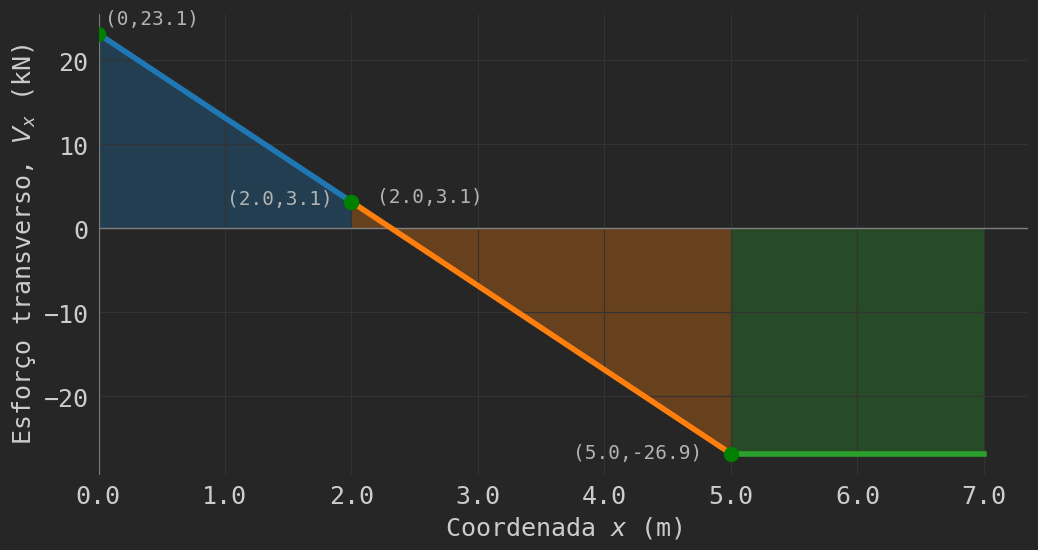

In [47]:
fz = 14
fig, ax = plt.subplots(figsize=(12,6))
plt.axhline(linewidth=1,color=(.5, .5, .5)); plt.axvline(linewidth=3,color=(.5, .5, .5))
plt.plot(xAB,yVAB,linewidth=4); plt.fill_between(xAB,yVAB, alpha=.3)
plt.plot(xBC,yVBC,linewidth=4); plt.fill_between(xBC,yVBC, alpha=.3)
plt.plot(xCD,yVCD,linewidth=4); plt.fill_between(xCD,yVCD, alpha=.3)
plt.xlabel('Coordenada $x$ (m)'); plt.ylabel('Esforço transverso, $V_{x}$ (kN)')
plt.plot(xAB[0],yVAB[0],'go',markersize=10)
plt.text(xAB[0]+.05,yVAB[0]*1.05,f'({xAB[0]:.0f},{yVAB[0]:.1f})',fontsize=fz)
plt.plot(xAB[-1],yVAB[-1],'go',markersize=10)
plt.text(xAB[-1]*.51,yVAB[-1]*.9,f'({xAB[-1]:.1f},{yVAB[-1]:.1f})',fontsize=fz)
plt.plot(xBC[0],yVBC[0],'go',markersize=10)
plt.text(xBC[0]*1.1,yVBC[0]*1.,f'({xBC[0]:.1f},{yVBC[0]:.1f})',fontsize=fz)
plt.plot(xBC[-1],yVBC[-1],'go',markersize=10)
plt.text(xBC[-1]*.75,yVBC[-1]*1.02,f'({xBC[-1]:.1f},{yVBC[-1]:.1f})',fontsize=fz)
plt.xlim(0,d.AD*1.05)
ax.xaxis.set_ticks_position('none'); ax.yaxis.set_ticks_position('none')
xrang = np.arange(0, d.AD*1.1, 1.)
ax.set_xticks(xrang); ax.set_xticklabels([i for i in xrang])
plt.grid(True); plt.show()

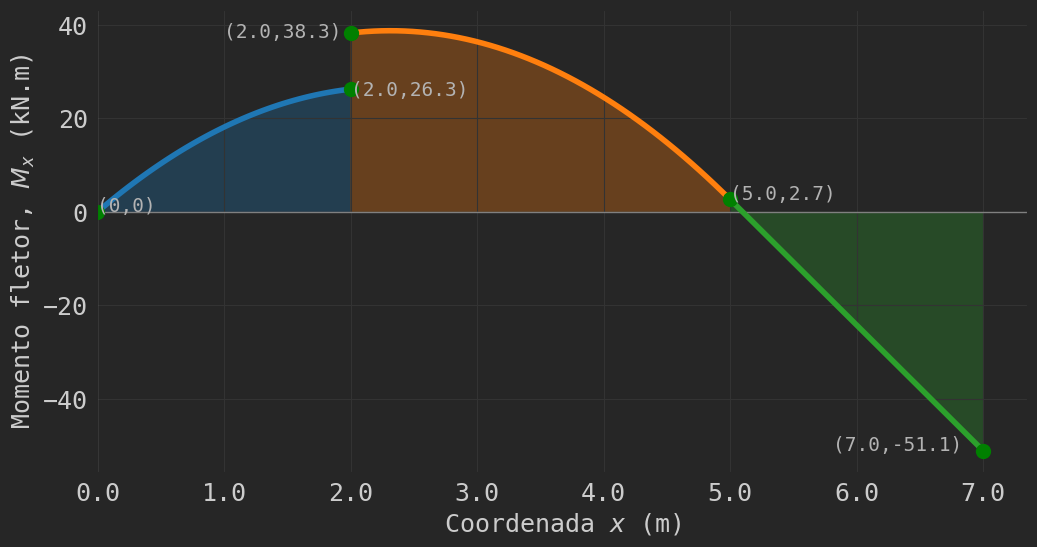

In [48]:

fig, ax = plt.subplots(figsize=(12,6))
plt.axhline(linewidth=1,color=(.5, .5, .5)); plt.axvline(linewidth=1,color=(.5, .5, .5))
plt.plot(xAB,yMAB,linewidth=4); plt.fill_between(xAB,yMAB, alpha=.3)
plt.plot(xBC,yMBC,linewidth=4); plt.fill_between(xBC,yMBC, alpha=.3)
plt.plot(xCD,yMCD,linewidth=4); plt.fill_between(xCD,yMCD, alpha=.3)
plt.xlabel(r'Coordenada $x$ (m)'); plt.ylabel(r'Momento fletor, $M_{x}$ (kN.m)')
plt.plot(xAB[0],yMAB[0],'go',markersize=10)
plt.text(xAB[0],yMAB[0]+.1,f'({xAB[0]:.0f},{yMAB[0]:.0f})',fontsize=fz)
plt.plot(xAB[-1],yMAB[-1],'go',markersize=10)
plt.text(xAB[-1]*1.,yMAB[-1]*.95,f'({xAB[-1]:.1f},{yMAB[-1]:.1f})',fontsize=fz)
plt.plot(xBC[0],yMBC[0],'go',markersize=10)
plt.text(xBC[0]*.5,yMBC[0]*.975,f'({xBC[0]:.1f},{yMBC[0]:.1f})',fontsize=fz)
plt.plot(xBC[-1],yMBC[-1],'go',markersize=10)
plt.text(xBC[-1]*1.,yMBC[-1],f'({xBC[-1]:.1f},{yMBC[-1]:.1f})', fontsize=fz)
plt.plot(xCD[-1],yMCD[-1],'go',markersize=10)
plt.text(xCD[-1]*.83,yMCD[-1],f'({xCD[-1]:.1f},{yMCD[-1]:.1f})', fontsize=fz)
plt.xlim(0,d.AD*1.05)
ax.xaxis.set_ticks_position('none'); ax.yaxis.set_ticks_position('none')
xrang = np.arange(0, d.AD*1.1, 1.0)
ax.set_xticks(xrang); ax.set_xticklabels([i for i in xrang])
plt.grid(True); plt.show()

## Resumo: Equação da elástica

A equação $y(x)$ descreve a localização do eixo da viga na posição deformada pela acção do momento fletor. Esta equação é conhecida como equação da linha elástica, e pode ser obtida na prática por dupla integração da equação do momento fletor ao longo da viga. A equação resultante deve ainda satisfazer as condições de fronteira do problema, ou seja, ser cinematicamente admissível. Esta condição permitirá determinar nomeadamente as constantes de integração resultantes do processo matemática de integração.

A hipótese de Euler-Bernoulli para o problema de flexão de uma viga conduz à seguinte equação,

\begin{equation*}
\varepsilon_{xx} = -\frac{y}{\rho}
\end{equation*}

Assumindo ainda a lei de Hooke para o comportamento linear elástico do materia, $\sigma_{xx} = E \varepsilon_{xx}$, pode obter-se uma relação entre o momento flector $M(x)$
e o raio de curvatura da superfície neutra da viga $\rho$,

\begin{equation*}
\sigma_{xx} = E \varepsilon_{xx} =
-\frac{yE}{\rho}
\quad\wedge\quad
\sigma_{xx} = -\frac{My}{I_z}
\quad\therefore\quad
\frac{1}{\rho} = \frac{M}{EI_z}
\end{equation*}

Considerando agora a relação entre o raio de curvatura $\rho$ e as segundas derivadas da função $y(x)$, que para pequenos valroes resulta,

\begin{equation*}
\frac{1}{\rho} \approx \frac{\mathrm{d}² y}{\mathrm{d}x²}
\end{equation*}

obtém-se finalmente,

\begin{equation*}
\frac{\mathrm{d}² y}{\mathrm{d} x²}
= \frac{M}{EI_z}
\end{equation*}

Assim sendo, para se obter a equação da elástica da viga do problema, $y(x)$, é necessário:

1. Escrever a equação do momento fletor na viga, M(x) - nomeadamente usando funções de singularidasde;

2. Integrar duas vezes essa equação;

3. Aplicar condições fronteira para calcular as duas constantes que surgem durante a integração.


### Apêndice A: Equação da elástica

A equação $y(x)$ descreve a posição deformada do eixo da viga devido à ação do momento fletor. Esta equação é conhecida como a equação da linha elástica e pode ser obtida na prática através da solução de uma equação diferencial por dupla integração da equação do momento fletor ao longo da viga. A equação resultante deve ainda satisfazer as condições de fronteira do problema, ou seja, ser cinematicamente admissível. Esta condição permitirá determinar, nomeadamente, as constantes de integração resultantes do processo de integração.

A hipótese de Euler-Bernoulli para o problema de flexão de uma viga conduz à seguinte equação,

\begin{equation*}
\varepsilon_{xx} = -\frac{y}{\rho}
\end{equation*}

Assumindo ainda a lei de Hooke para o comportamento linear elástico do materia, $\sigma_{xx} = E \varepsilon_{xx}$, pode obter-se uma relação entre o momento flector $M(x)$ e o raio de curvatura da superfície neutra da viga $\rho$,

\begin{equation*}
\sigma_{xx} = E \varepsilon_{xx} =
-\frac{yE}{\rho}
\quad\wedge\quad
\sigma_{xx} = -\frac{My}{I_z}
\quad\therefore\quad
\frac{1}{\rho} = \frac{M}{EI_z}
\end{equation*}

Considerando agora a relação entre o raio de curvatura $\rho$ e as segundas derivadas da função $y(x)$, que para pequenos valroes resulta,

\begin{equation*}
\frac{1}{\rho} \approx \frac{\mathrm{d}² y}{\mathrm{d} x²}
\end{equation*}

obtém-se finalmente,

\begin{equation*}
\frac{\mathrm{d}² y}{\mathrm{d} x²}
= \frac{M}{EI_z}
\end{equation*}

Assim sendo, para se obter a equação da elástica da viga do problema, $y(x)$, é necessário:

1. Escrever a equação do momento fletor na viga, $M(x)$ - nomeadamente usando funções de singularidasde;

2. Integrar duas vezes essa equação;

3. Aplicar condições fronteira para calcular as duas constantes que surgem durante a integração.


### Apêndice B: Funções de singularidade

As expressões $⟨x − a⟩^0$, $⟨x − a⟩^1$, $⟨x − a⟩^2$ são designadas por funçoes singulares. Quando $n ≥ 0$,

\begin{equation*}
⟨x − a⟩^n = 
\begin{cases}
(x − a)^n & \quad\text{se } x \ge a \\
0 & \quad\text{se } x < a \\
\end{cases}
\end{equation*}

Nota-se que, os parênteses angulares ⟨ ⟩ devem ser substituídos por parênteses curvos ( ) quando $x ≥ a$ e por zero quando $x < a$.

Segue da definição de funções singularidades que,

\begin{equation*}
\int ⟨x − a⟩^n \mathrm{d}x = \frac{1}{n+1} 
⟨x − a⟩^{n+1} \quad\textrm{se}\quad n \ge 0
\end{equation*}

e 

\begin{equation*}
\frac{d}{dx} ⟨x − a⟩^n = n⟨x − a⟩^{n-1} \quad\textrm{se}\quad n \ge 1
\end{equation*}

### Anexo: Funções de singularidade

<img src="https://userweb.fct.unl.pt/~jmc.xavier/MSII/Notebooks/Formulario/singularity_functions.png"
width="900">

---

Copyright (c) DEMI - FCT NOVA

Interactive computing by <a href="https://jupyter.org/" target="_blank"> <span
style="color:#333399"> Jupyter Notebook </span> </a> &nbsp;|&nbsp;Coded by <a href = "mailto: jmc.xavier@fct.unl.pt">José Xavier</a>

Licensed under  <a href="http://creativecommons.org/licenses/by-sa/4.0/"
target="_blank"> <span style="color:#333399;font-size: 20px"> CC BY-SA 4.0  </span></a>